In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import h5py
from datasets import ShapesDataset, DSpritesDataset

from utils.utils import load_model
from models import VAE_dsprites, VAE_shapes
import config

In [2]:
DATASET = config.dataset_name 
RESULTS_PATH = config.results_path

if DATASET not in ["3d_shapes", "dsprites"]:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")

DEFAULT_VAE_LOAD_MODEL_DIR = config.default_vae_load_model_dir
BETA_VAE_LOAD_MODEL_DIR = config.beta_vae_load_model_dir
CHAMPION_MODEL_NAME = config.champion_model_name

IMG_WIDTH_HEIGHT = config.img_width_height
NO_CHANNELS = config.no_channels
DISENTANGLEMENT_RANGE = config.disentanglement_range
DISENTANGLEMENT_STEPS = config.disentanglement_steps

print("---SETTINGS---")
print(f"dataset: {DATASET}")
print(f"loading directories:\n\t{DEFAULT_VAE_LOAD_MODEL_DIR}\n\t{BETA_VAE_LOAD_MODEL_DIR}")

---SETTINGS---
dataset: 3d_shapes
loading directories:
	default_VAE_3d_shapes
	beta_VAE_3d_shapes


In [3]:
hyperparameters = {
    "device": config.device,
    "latent_dim": config.latent_dim,
}

print("\n---HYPERPARAMETERS---")
for key, value in hyperparameters.items():
    print(f"{key}: {value}")


---HYPERPARAMETERS---
device: cuda
latent_dim: 6


# Loading images

In [4]:
# LOADING
if DATASET == "dsprites":
    dataset_zip = np.load('./data/dsprites_64x64.npz')
    images = dataset_zip['imgs']
    n_samples = images.shape[0]

elif DATASET == "3d_shapes":
    shapes_dataset = h5py.File('./data/3d_shapes.h5', 'r')
    
    shapes_labels = shapes_dataset['labels']  # array shape [480000,6], float64
    batch_images = shapes_dataset['images']  # array shape [480000,64,64,3], uint8 in range(256)
    images = np.array(batch_images)
    
    shapes_image_shape = batch_images.shape[1:]  # [64,64,3]
    shapes_label_shape = shapes_labels.shape[1:]  # [6]
    n_samples = shapes_labels.shape[0]

else:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")

images_shuffled = images[np.random.permutation(n_samples)]

# CREATE DATALOADERS
if DATASET == "dsprites":
    loader = DataLoader(DSpritesDataset(images_shuffled), batch_size=16)

elif DATASET == "3d_shapes":
    loader = DataLoader(ShapesDataset(images_shuffled), batch_size=16)

else:
    raise ValueError("DATASET must be one of 'dsprites', '3d_shapes'")

In [5]:
def show_images_grid(imgs, nrows=2, labels=None):
    imgs = imgs.detach().cpu()
    ncols = 8
    _, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.reshape(nrows, ncols)  # Grid-Form behalten

    for row in range(nrows):
        for col in range(ncols):
            ax_i = row * ncols + col
            ax = axes[row, col]

            if ax_i < len(imgs):
                img = imgs[ax_i]

                if img.shape[0] == 3:  # RGB
                    img = img.permute(1, 2, 0)  # CxHxW → HxWxC
                    ax.imshow(img, interpolation='nearest')
                elif img.shape[0] == 1:  # Grayscale
                    img = img.squeeze(0)  # 1xHxW → HxW
                    ax.imshow(img, cmap='gray', interpolation='nearest')
                else:
                    raise ValueError(f"Unerwartete Channel-Zahl: {img.shape[0]}")

                ax.set_xticks([])
                ax.set_yticks([])
            else:
                ax.axis('off')

        # Label für die Zeile links neben der ersten Spalte
        if labels is not None and row < len(labels):
            axes[row, 0].set_ylabel(labels[row], fontsize=32, rotation=90, labelpad=30, va='center')

    plt.tight_layout()
    plt.show()

# Sample images from dataset

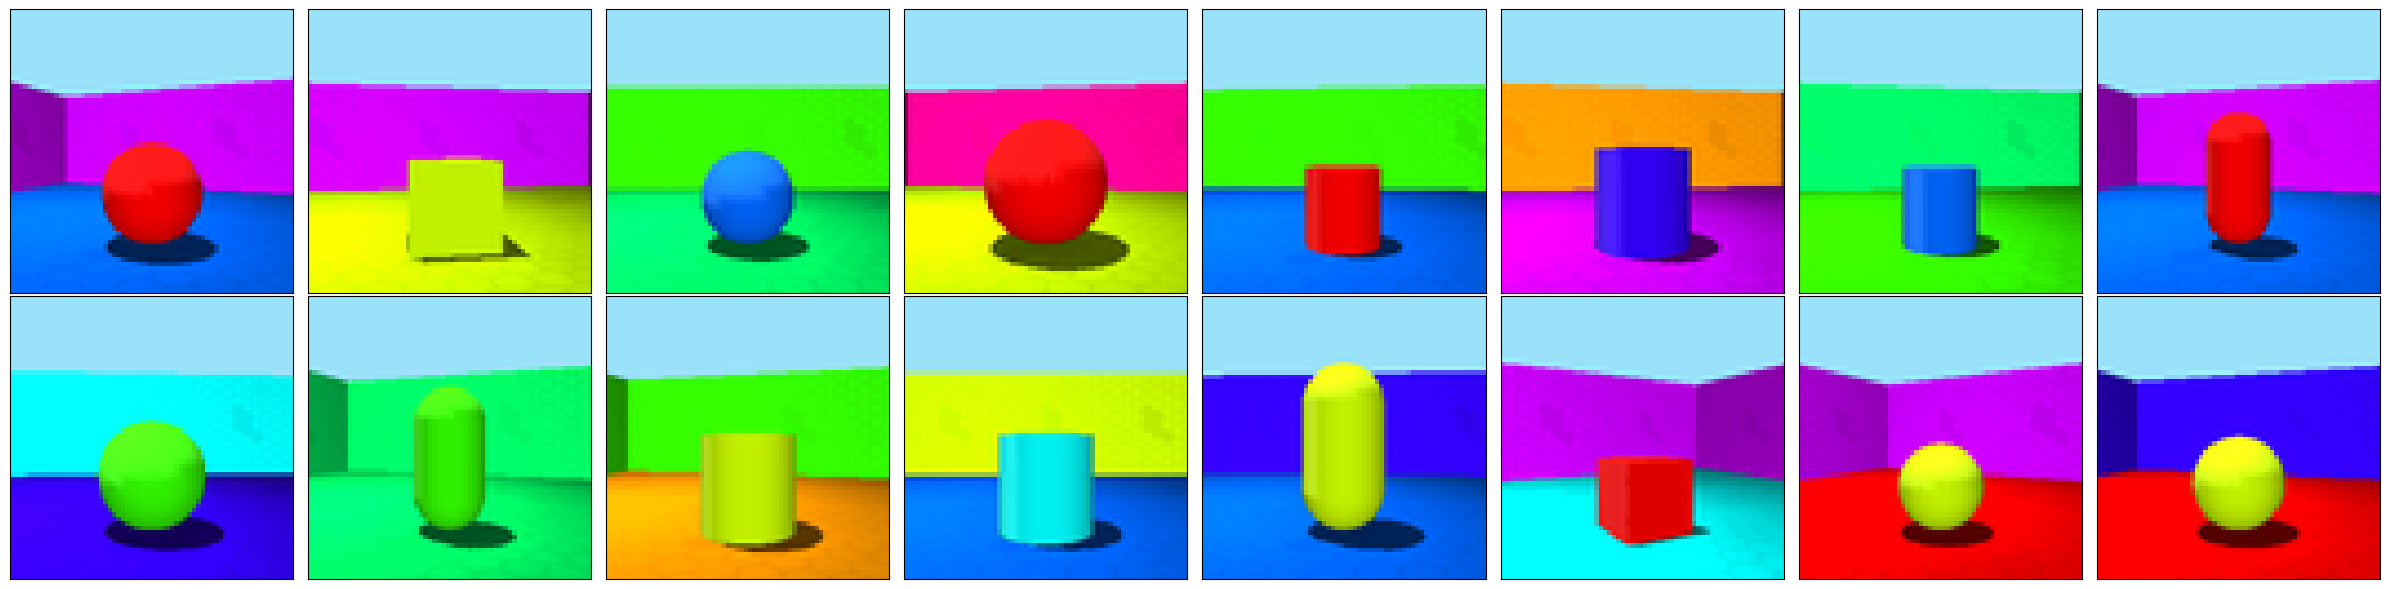

In [6]:
# Get a batch of images
dataiter = iter(loader)
batch_images = next(dataiter)
show_images_grid(batch_images)

# Visualize Reconstruction

In [7]:
# Load model
beta_VAE_path = os.path.join(RESULTS_PATH, BETA_VAE_LOAD_MODEL_DIR, f"{CHAMPION_MODEL_NAME}.pth")
default_VAE_path = os.path.join(RESULTS_PATH, DEFAULT_VAE_LOAD_MODEL_DIR, f"{CHAMPION_MODEL_NAME}.pth")
if DATASET == "dsprites":
    beta_vae_model = load_model(VAE_dsprites(latent_dim=hyperparameters['latent_dim']), path=beta_VAE_path, hyperparameters=hyperparameters).to(hyperparameters['device'])
    default_vae_model = load_model(VAE_dsprites(latent_dim=hyperparameters['latent_dim']), path=default_VAE_path, hyperparameters=hyperparameters).to(hyperparameters['device'])
elif DATASET == "3d_shapes":
    beta_vae_model = load_model(VAE_shapes(latent_dim=hyperparameters['latent_dim']), path=beta_VAE_path, hyperparameters=hyperparameters).to(hyperparameters['device'])
    default_vae_model = load_model(VAE_shapes(latent_dim=hyperparameters['latent_dim']), path=default_VAE_path, hyperparameters=hyperparameters).to(hyperparameters['device'])

Model loaded from ./results/beta_VAE_3d_shapes/champion.pth
Model loaded from ./results/default_VAE_3d_shapes/champion.pth


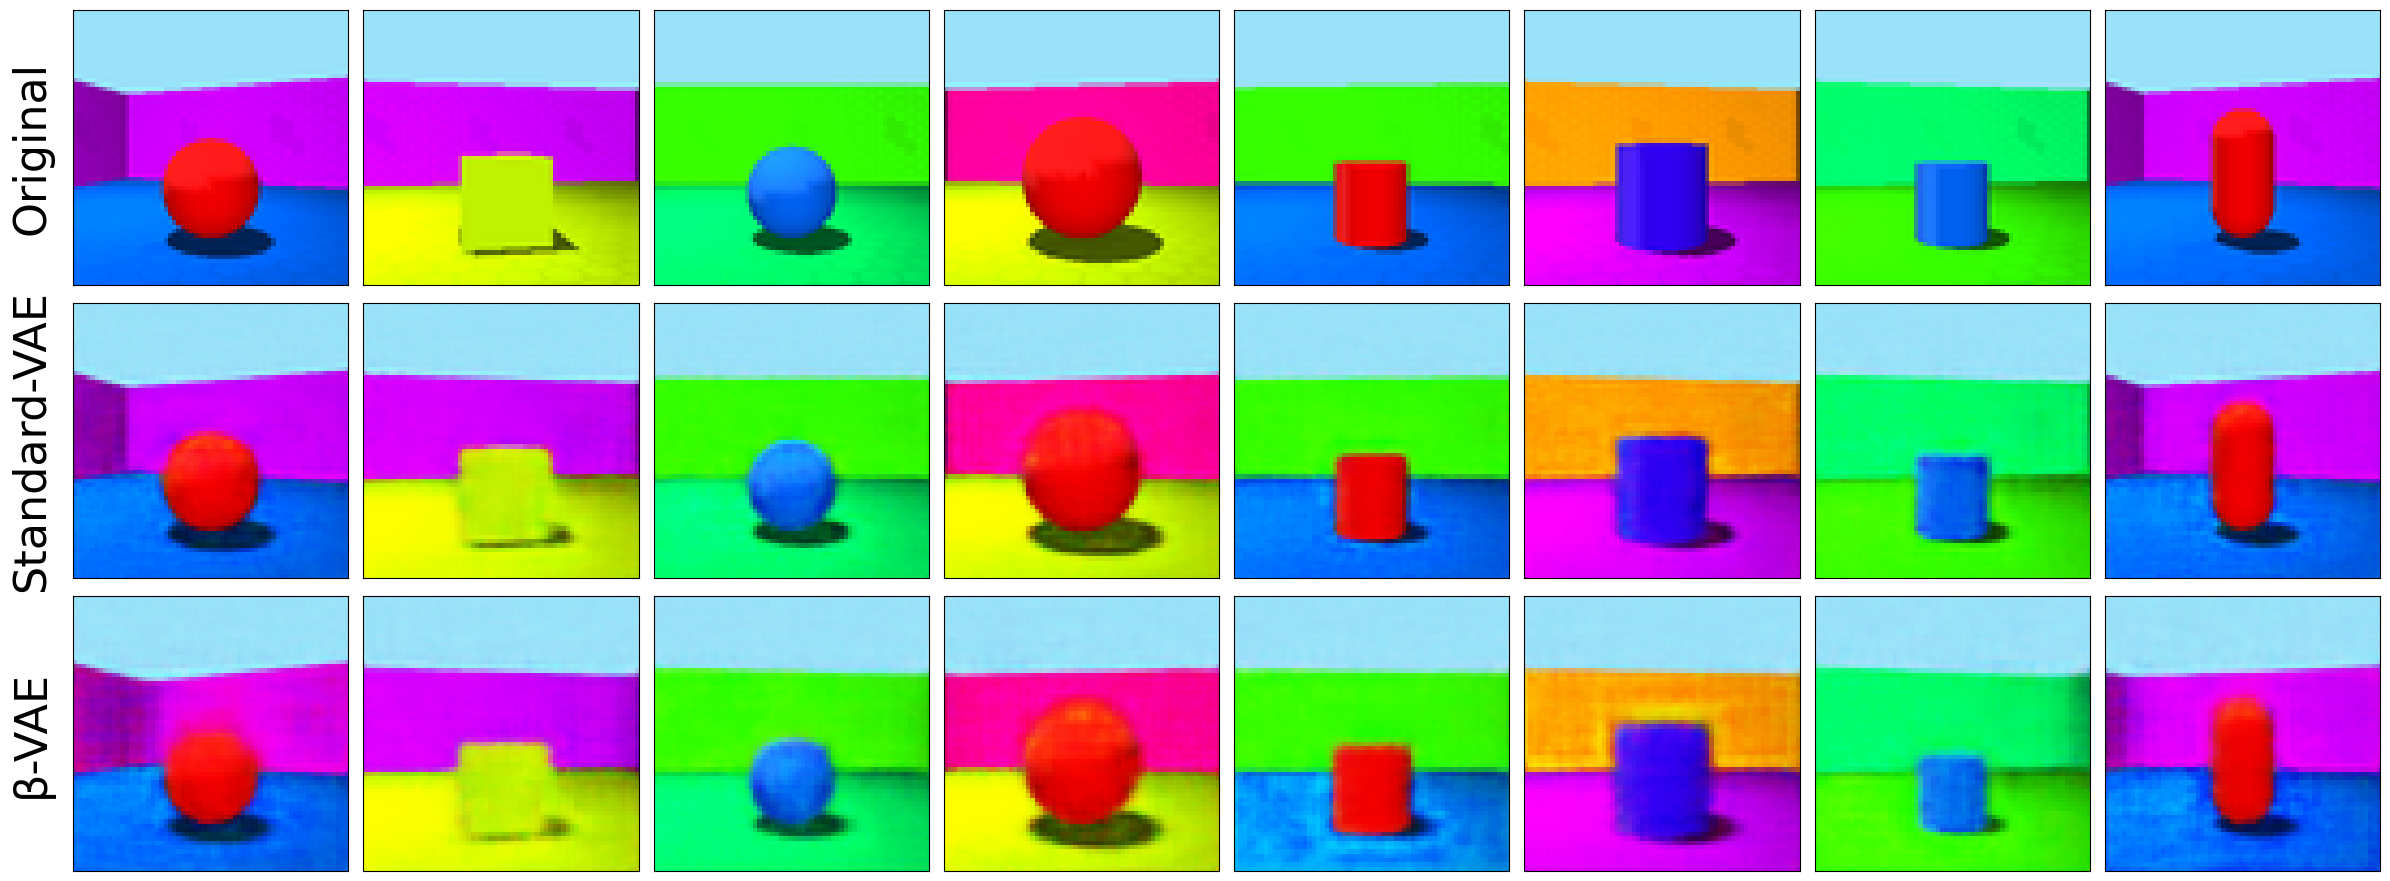

In [8]:
with torch.no_grad():
        data = batch_images.to(hyperparameters['device'])
        default_vae_recon_batch, mu, logvar = default_vae_model(data)
        beta_vae_recon_batch, mu, logvar = beta_vae_model(data)
        
        
        comparison = torch.cat([
                data[:8], 
                default_vae_recon_batch.view(16, NO_CHANNELS, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT)[:8],
                beta_vae_recon_batch.view(16, NO_CHANNELS, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT)[:8]
        ])
        show_images_grid(comparison, nrows=3, labels=['Original', 'Standard-VAE', 'β-VAE'])

# Latent Space Traversal

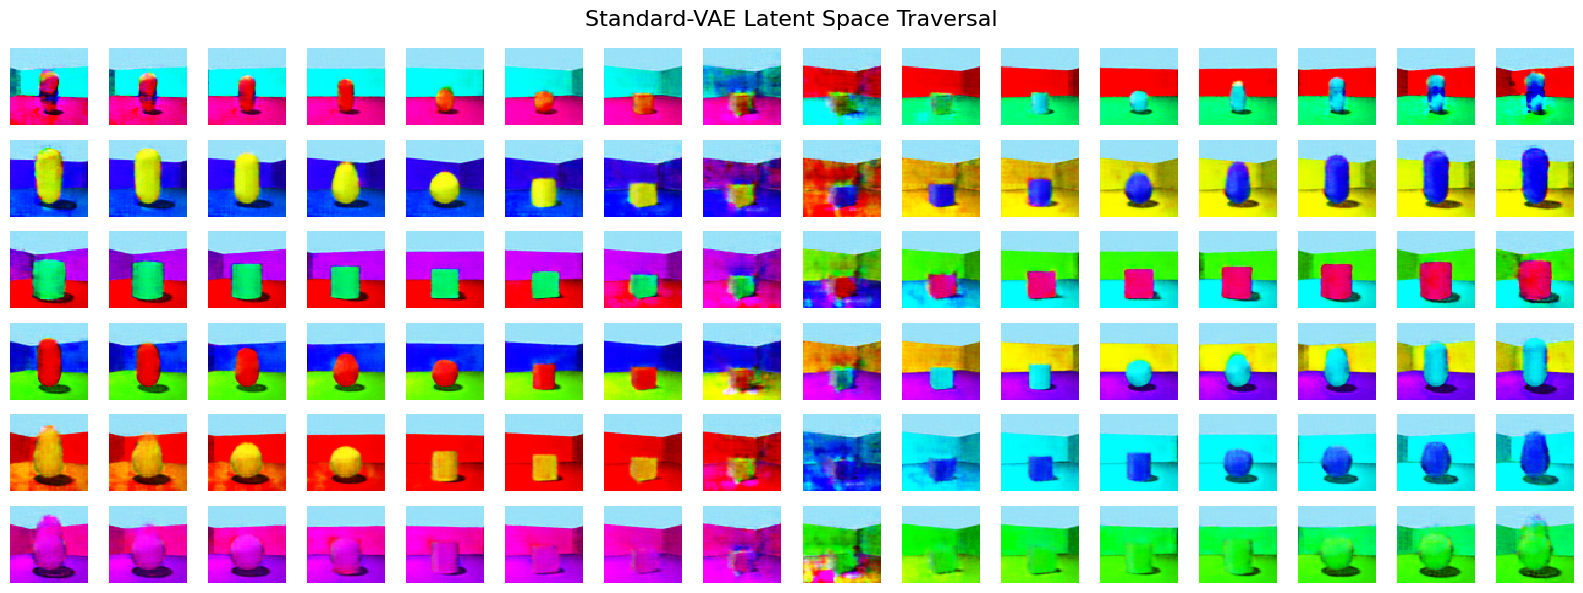

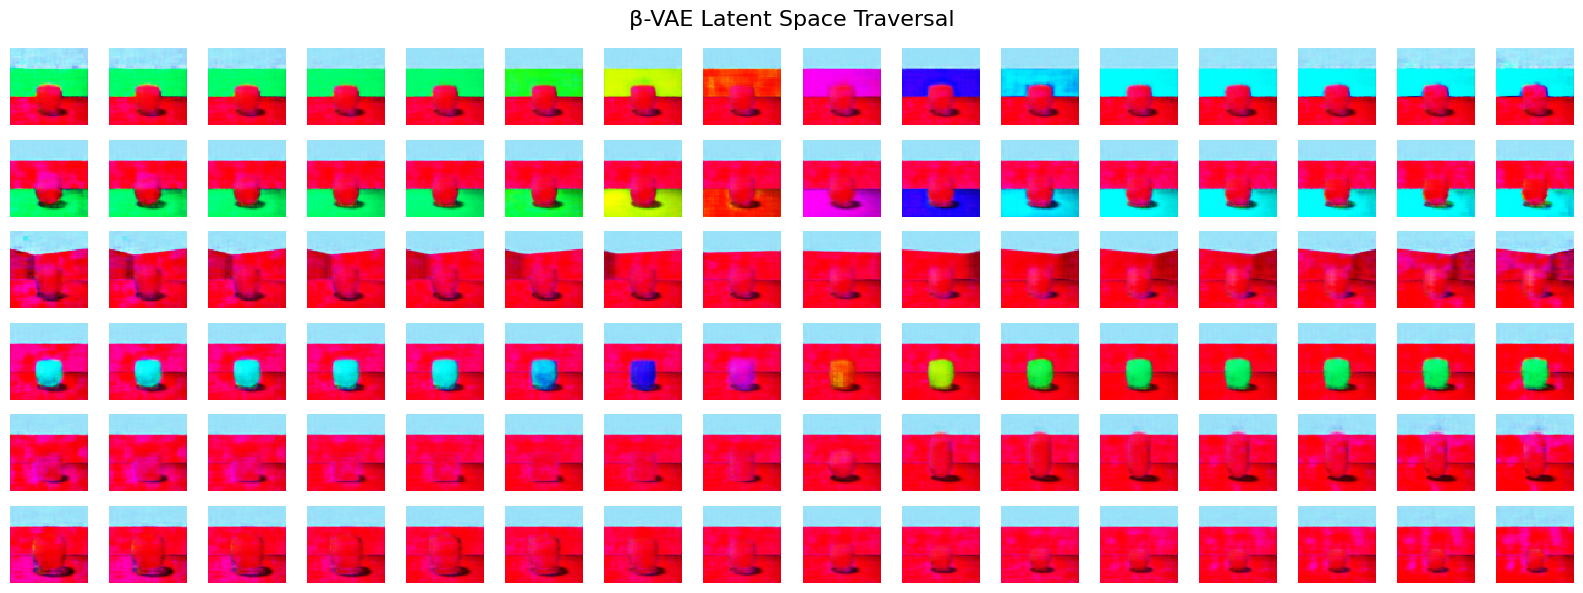

In [9]:
def sample_images_from_latent_space(model):
    test_viz_imgs = []
    with torch.no_grad():
        z = torch.zeros(hyperparameters['latent_dim'])
        for z_param in range(hyperparameters['latent_dim']):
            row_imgs = []
            for val in torch.linspace(DISENTANGLEMENT_RANGE[0], DISENTANGLEMENT_RANGE[1], DISENTANGLEMENT_STEPS): # tensor with DISENTANGLEMENT_STEPS values ranging from DISENTANGLEMENT_RANGE[0] to DISENTANGLEMENT_RANGE[1]
                z_copy = z.clone().to(hyperparameters['device']) 
                z_copy[z_param] = val  # change one dimension of latent vector
                img = model.decode(z_copy.unsqueeze(0)) # decode latent vector and add batch dimension
                row_imgs.append(img.view(NO_CHANNELS, IMG_WIDTH_HEIGHT, IMG_WIDTH_HEIGHT).cpu().numpy()) 
            test_viz_imgs.append(row_imgs)
    return test_viz_imgs
        

def plot_latent_space_traversal(images, model):
    _, axes = plt.subplots(nrows=hyperparameters['latent_dim'], ncols=DISENTANGLEMENT_STEPS, figsize=(DISENTANGLEMENT_STEPS, hyperparameters['latent_dim']))
    for dim in range(hyperparameters['latent_dim']):
        for step in range(DISENTANGLEMENT_STEPS):

            ax = axes[dim, step]

            # for RGB images
            if images[dim][step].shape[0] == 3:
                images[dim][step] = torch.tensor(images[dim][step]).permute(1, 2, 0).numpy()  # CxHxW → HxWxC
                ax.imshow(images[dim][step], interpolation='nearest')
            
            # for grayscale images
            elif images[dim][step].shape[0] == 1:  # Grayscale
                images[dim][step] = torch.tensor(images[dim][step]).squeeze(0).numpy()  # 1xHxW → HxW
                ax.imshow(images[dim][step], cmap='gray', interpolation='nearest')
            
            else:
                raise ValueError(f"Unexpected number of channels: {images[0].shape[0]}")
            
            ax.axis('off')

    plt.suptitle(f"{model}-VAE Latent Space Traversal", fontsize=16)
    plt.tight_layout()
    plt.show()

default_vae_images = sample_images_from_latent_space(default_vae_model)
beta_vae_images = sample_images_from_latent_space(beta_vae_model)

plot_latent_space_traversal(default_vae_images, model="Standard")
plot_latent_space_traversal(beta_vae_images, model="β")